# LKIPA Resonance v.s. Temperature Analysis
---




In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import h5py
import inspect
from tqdm import tqdm
import sys
import math
import glob
import matplotlib.cm as cm
import matplotlib.colors as mcolors
%matplotlib widget

# Reload credentials module to get latest changes
import importlib

# # Import scripts for JPA AND LKIPA planck spectroscopy
# import JPA_planck_spec as jps
# import LKIPA_planck_spec as lps
import LKIPA_resonance_PSD as psd
importlib.reload(psd)

<module 'LKIPA_resonance_PSD' from '/home/nanophys-meas/Desktop/Jai Master Thesis/Presto-Measurement-Scripts/Planck/LKIPA_resonance_PSD.py'>

## 1. Extract all fitting parameters for each temperature
---

In [2]:
# Load experiment data
def load_time_series_data(file_):
    with h5py.File(file_, "r") as dataset:
        run_key = list(dataset.keys())[0]   # this is your myrun
        grp = dataset[run_key]

        return {
            "run": run_key,
            "sample": grp["sample"][()],
            "df": np.asarray(grp["df"]),
            # "time_series": np.asarray(grp["Time Series Data"]),
            "dt": np.asarray(grp["dt"]),
            "n_pix": np.asarray(grp["Pixels"]),
            "n_samples": np.asarray(grp["Samples per pixel"]),
            "temp": np.asarray(grp["Temperature"]),
            "fit_params": np.asarray(grp["Fit parameters"]),
        }

## 1.1 Loop over hdf5 files


In [3]:
folder = "/media/nanophys-meas/DR_BACKUP/Planck Spectroscopy 2026-04/LKIPA Resonance 2026-04/"
files = glob.glob(os.path.join(folder, "*.hdf5"))[:-1]

fitting_params_list = np.zeros((len(files), 5))  
temp_list = np.zeros(len(files))

with tqdm(files, desc="Processing files") as pbar:
    for idx, file in enumerate(pbar):
        data_test = load_time_series_data(file)
        temp_str = str(int(np.round(np.real(data_test["temp"]), 2)))

        # if 0.15 <= data_test["fit_params"][2] <= 0.2:
        fitting_params_list[idx] = np.real(data_test["fit_params"])
        temp_list[idx] = float(temp_str)
        
        pbar.set_postfix(temp=f"{temp_str} mK", status="fit ok")

        np.savetxt(f"LKIPA Resonance Fitting 2026-04/fit_params_{temp_str}mK.txt", np.real(data_test["fit_params"]))

            # continue

        # pbar.set_postfix(temp=f"{temp_str} mK", status="refitting")

        # I_all = psd.remove_DC(data_all=data_test["time_series"])

        # PSD_avg, f_arr, t_arr = psd.get_PSD_avg(
        #     I_all=I_all,
        #     n_samples=int(np.real(data_test["n_samples"])),
        #     dt=data_test["dt"]
        # )

        # PSD_bw, f_bw = psd.get_PSD_bw(
        #     PSD_avg=PSD_avg,
        #     f_arr=f_arr,
        #     f_L=0.42,
        #     f_R=0.44,
        # )

        # fit_params = np.real(psd.lorentz_fit(
        #     PSD_bandwidth=PSD_bw,
        #     f_arr_bandwidth=f_bw,
        #     lorentzian_fit_func=psd.lorentzian_fit_func,
        #     verbose=False,
        # ))

        # fitting_params_list[idx] = fit_params
        # temp_list[idx] = float(temp_str)

        # np.savetxt(f"LKIPA Resonance Fitting/fit_params_{temp_str}mK.txt", fit_params)

        # pbar.set_postfix(temp=f"{temp_str} mK", status="new fit ok")

Processing files: 100%|██████████| 64/64 [00:00<00:00, 246.94it/s, status=fit ok, temp=593 mK]


## 1.2 Plot
----

### 1.2.1 Fit Parameters

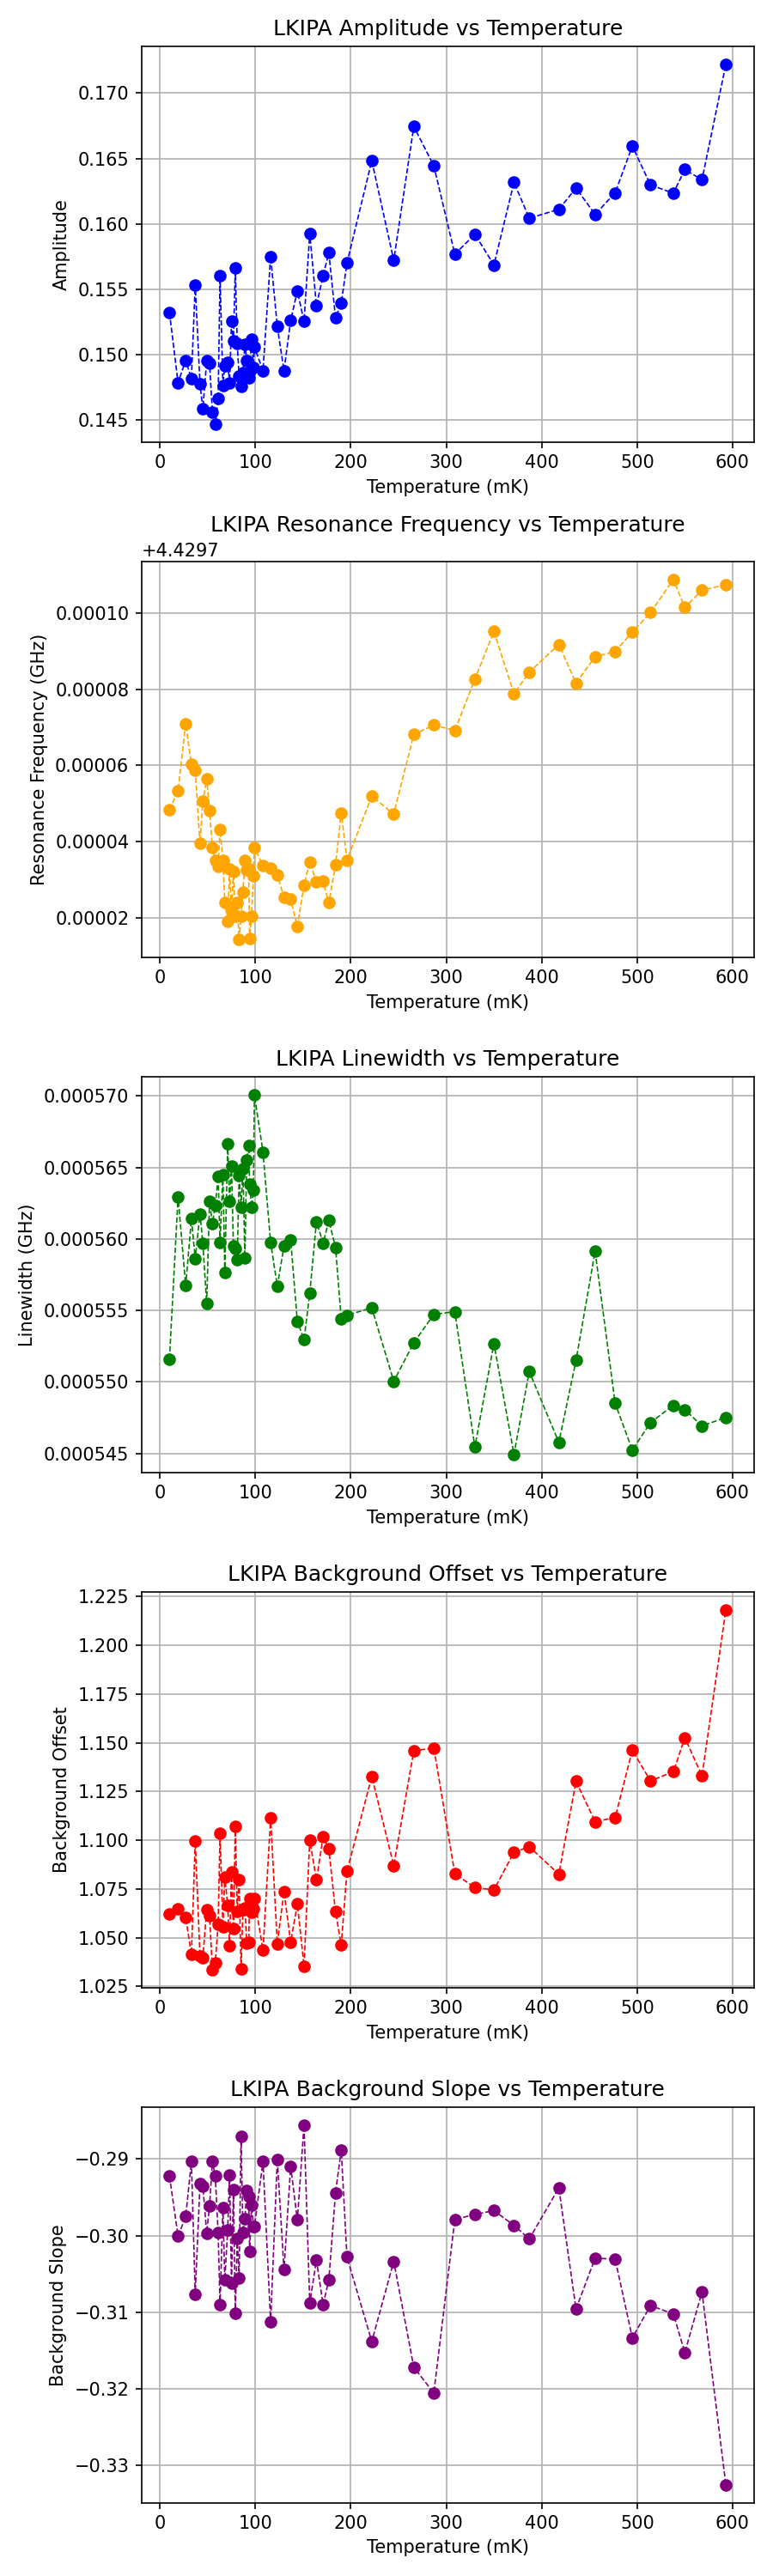

In [4]:
temp_ascending = np.argsort(temp_list)
fitting_params_list = fitting_params_list[temp_ascending]
temp_list = temp_list[temp_ascending]

# from fit parameters, extract amplitude, resonance frequency, and linewidth
A = fitting_params_list[:, 2] # Amplitude from fit
f0 = 4 + fitting_params_list[:, 3] # Resonance frequency from fit
gamma = np.abs(fitting_params_list[:, 4]) # Linewidth from fit

a_bg = fitting_params_list[:, 0] # Background offset from fit
b_bg = fitting_params_list[:, 1] # Background slope from fit

# PLOT
fig, ax = plt.subplots(figsize=(6, 20), nrows=5, dpi=150)

ax1, ax2, ax3, ax4, ax5 = ax

ax1.plot(temp_list, A, color='blue', label='LKIPA Amplitude', lw=0.8, ls='--', marker = 'o')
ax1.set_xlabel("Temperature (mK)")
ax1.set_ylabel("Amplitude")
ax1.set_title("LKIPA Amplitude vs Temperature")
ax1.grid()

ax2.plot(temp_list, f0, color='orange', label='LKIPA Resonance Frequency', lw=0.8, ls='--', marker = 'o')
ax2.set_xlabel("Temperature (mK)")
ax2.set_ylabel("Resonance Frequency (GHz)")
ax2.set_title("LKIPA Resonance Frequency vs Temperature")
ax2.grid()

ax3.plot(temp_list, gamma, color='green', label='LKIPA Linewidth', lw=0.8, ls='--', marker = 'o')
ax3.set_xlabel("Temperature (mK)")
ax3.set_ylabel("Linewidth (GHz)")
ax3.set_title("LKIPA Linewidth vs Temperature")
ax3.grid()

ax4.plot(temp_list, a_bg, color='red', label='LKIPA Background Offset', lw=0.8, ls='--', marker = 'o')
ax4.set_xlabel("Temperature (mK)")
ax4.set_ylabel("Background Offset")
ax4.set_title("LKIPA Background Offset vs Temperature")
ax4.grid()

ax5.plot(temp_list, b_bg, color='purple', label='LKIPA Background Slope', lw=0.8, ls='--', marker = 'o')
ax5.set_xlabel("Temperature (mK)")
ax5.set_ylabel("Background Slope")
ax5.set_title("LKIPA Background Slope vs Temperature")
ax5.grid()

fig.tight_layout()


### 1.2.2 Integral of PSD - Formula

$$

\boxed{
    \int_{0}^{\infty} df \frac{A}{1 + ((f - f_0)/\gamma)^2} = A\gamma \left( \pi/2 - \tan^{-1}(f_0/ \gamma)   \right)
}

$$

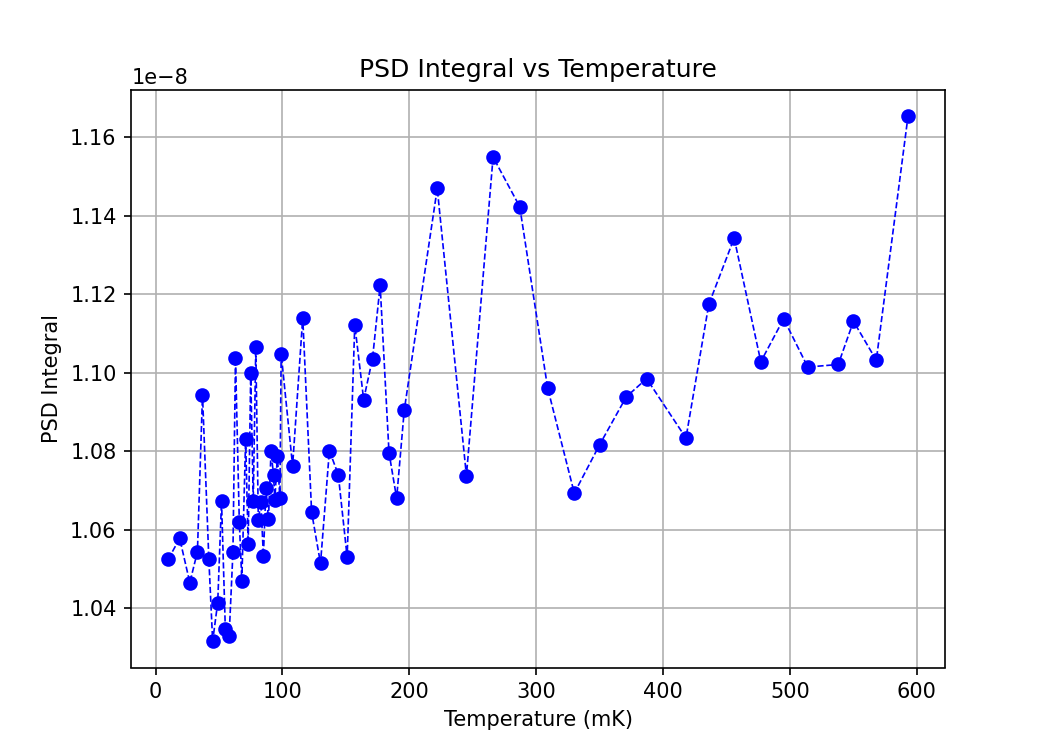

In [9]:
PSD_integral = (A * gamma) * (np.pi/2 - (np.arctan(f0 / gamma)))

# PLOT

fig, ax = plt.subplots(figsize=(7, 5), dpi=150)
ax.plot(temp_list, PSD_integral, color='blue', label='PSD Integral', lw=0.8, ls='--', marker = 'o')
ax.set_xlabel("Temperature (mK)")
ax.set_ylabel("PSD Integral")
ax.set_title("PSD Integral vs Temperature")
ax.grid()

### 1.2.3 Integral of PSD across bandwidth

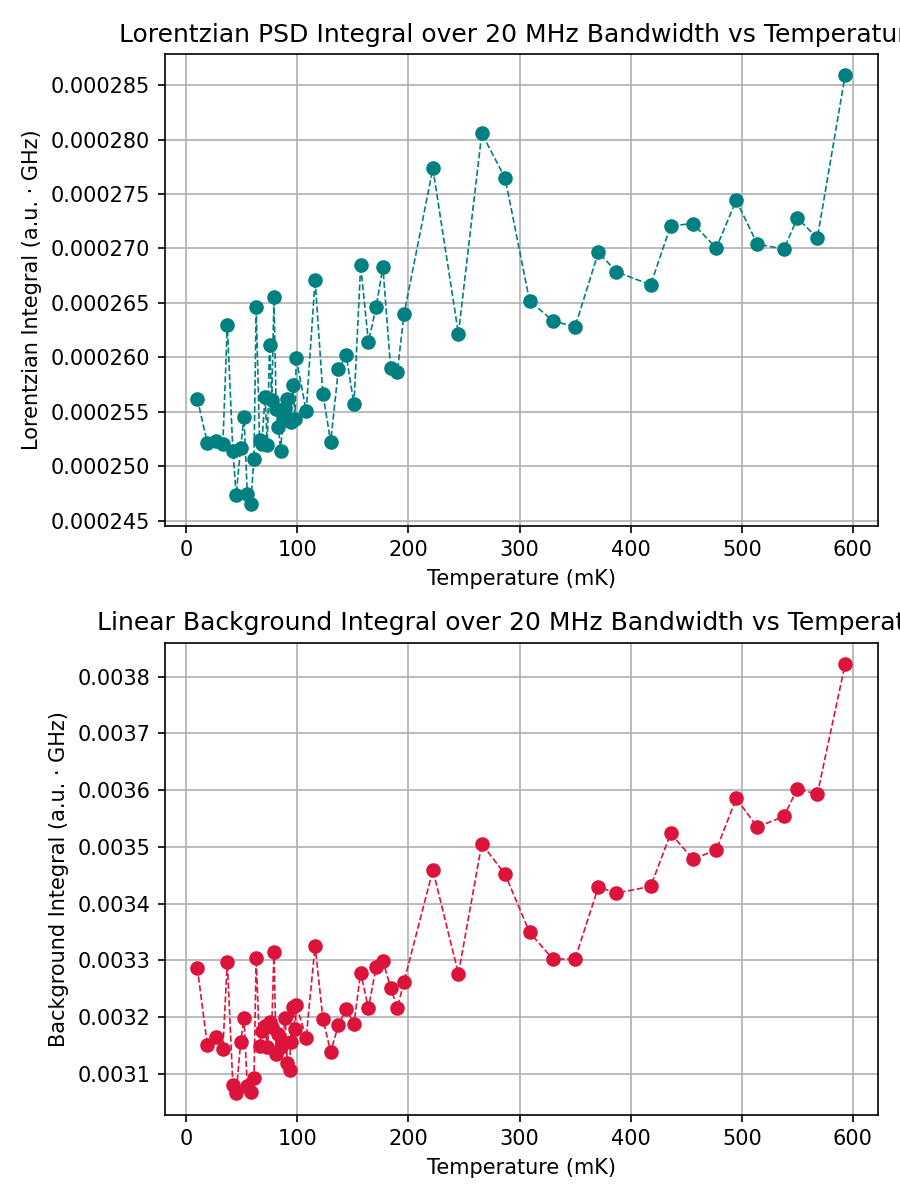

In [8]:
from scipy.integrate import quad

# 20 MHz bandwidth = 0.02 GHz, centered on resonance
BW = 0.02        # GHz
half_BW = BW / 2

# IF resonance frequency (offset from 4 GHz NCO, used in the fit)
f0_IF = fitting_params_list[:, 3]  # GHz, ~ 0.428

lorentz_integral_bw = np.zeros(len(temp_list))
bg_integral_bw      = np.zeros(len(temp_list))

for i in range(len(temp_list)):
    f_L = f0_IF[i] - half_BW
    f_R = f0_IF[i] + half_BW

    lorentz_integral_bw[i] = quad(
        lambda f: A[i] / (((f - f0_IF[i]) / gamma[i]) ** 2 + 1),
        f_L, f_R
    )[0]

    bg_integral_bw[i] = quad(
        lambda f: a_bg[i] * f + b_bg[i],
        f_L, f_R
    )[0]

# PLOT
fig, ax = plt.subplots(figsize=(6, 8), nrows=2, dpi=150)
ax1, ax2 = ax

ax1.plot(temp_list, lorentz_integral_bw, color='teal', lw=0.8, ls='--', marker='o')
ax1.set_xlabel("Temperature (mK)")
ax1.set_ylabel("Lorentzian Integral (a.u. · GHz)")
ax1.set_title("Lorentzian PSD Integral over 20 MHz Bandwidth vs Temperature")
ax1.grid()

ax2.plot(temp_list, bg_integral_bw, color='crimson', lw=0.8, ls='--', marker='o')
ax2.set_xlabel("Temperature (mK)")
ax2.set_ylabel("Background Integral (a.u. · GHz)")
ax2.set_title("Linear Background Integral over 20 MHz Bandwidth vs Temperature")
ax2.grid()

fig.tight_layout()